In [ ]:
!pip install ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.7/27.7 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.1/321.1 kB 25.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.31.1 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.31.1 which is incompatib

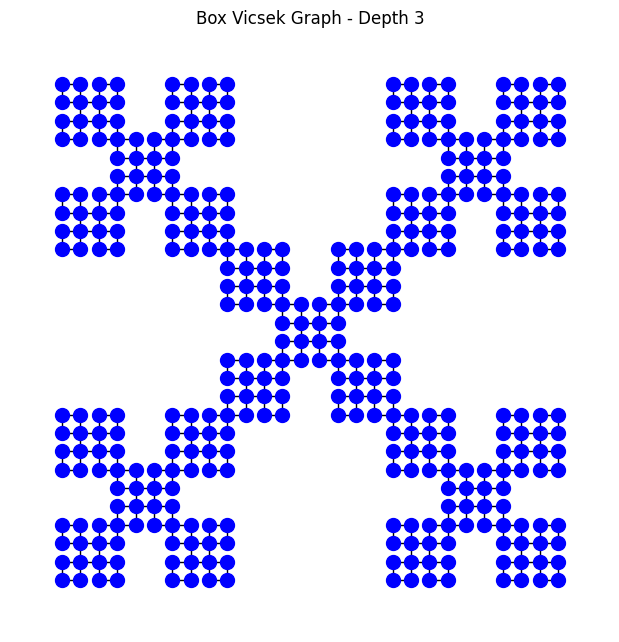

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def build_box_vicsek_graph(depth):
    squares = {(0, 0)}
    copy_offsets = [(0,0), (2,0), (0,2), (2,2), (1,1)]

    for _ in range(depth):
        new_squares = set()
        for (x, y) in squares:
            for dx, dy in copy_offsets:
                new_squares.add((3*x + dx, 3*y + dy))
        squares = new_squares

    vertices = set()
    edges = set()

    for (x, y) in squares:
        v0 = (x, y)
        v1 = (x+1, y)
        v2 = (x+1, y+1)
        v3 = (x, y+1)
        verts = [v0, v1, v2, v3]
        for v in verts:
            vertices.add(v)
        square_edges = [(v0,v1),(v1,v2),(v2,v3),(v3,v0)]
        for a, b in square_edges:
            edges.add(tuple(sorted([a,b])))

    sorted_vertices = sorted(vertices)
    coord_to_node = {c:i for i,c in enumerate(sorted_vertices)}

    G = nx.Graph()
    for coord, nid in coord_to_node.items():
        G.add_node(nid, coord=coord)
    for a, b in edges:
        G.add_edge(coord_to_node[a], coord_to_node[b])

    pos = {coord_to_node[c]: (c[0], -c[1]) for c in sorted_vertices}  # flip y for display
    return G, pos

# Plot example: depth 1
depth = 3
G, pos = build_box_vicsek_graph(depth)
plt.figure(figsize=(6,6))
nx.draw(G, pos, node_size=100, node_color='blue', with_labels=False)
plt.axis('equal')
plt.title(f"Box Vicsek Graph - Depth {depth}")
plt.show()


Depth 1: vertices=16, edges=20
Graceful labeling found!
Vertex labels: {0: 0, 1: 20, 2: 19, 3: 10, 4: 18, 5: 1, 6: 3, 7: 6, 8: 16, 9: 2, 10: 15, 11: 4, 12: 11, 13: 17, 14: 7, 15: 14}
Edge labels: [18, 20, 19, 9, 16, 4, 17, 1, 2, 3, 12, 14, 5, 13, 15, 8, 11, 10, 6, 7]


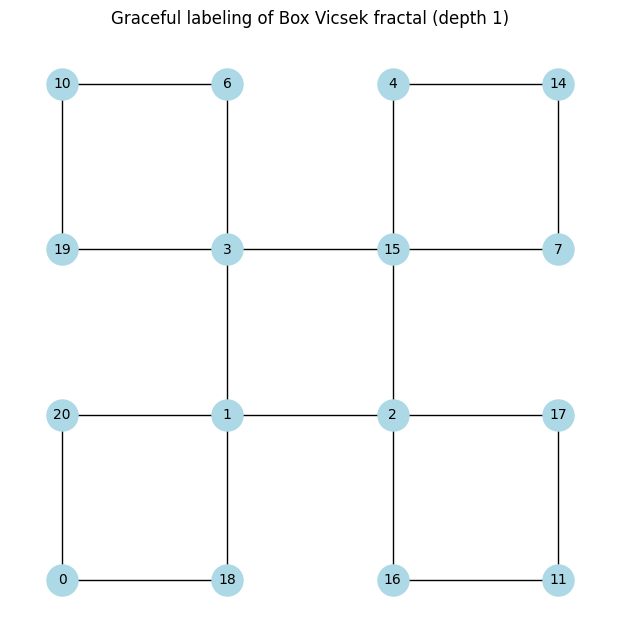

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from ortools.sat.python import cp_model


def build_box_vicsek(depth: int):
    """Construct the box Vicsek fractal graph (square polygonal system)."""
    squares = {(0,0)}
    copy_offsets = [(0,0), (0,2), (2,0), (2,2), (1,1)]
    for _ in range(depth):
        new_squares = set()
        for (x,y) in squares:
            for dx,dy in copy_offsets:
                new_squares.add((3*x + dx, 3*y + dy))
        squares = new_squares

    vertices = set()
    edges = set()
    for (x,y) in squares:
        v0 = (x,y); v1 = (x+1,y); v2 = (x+1,y+1); v3 = (x,y+1)
        verts = [v0,v1,v2,v3]
        for v in verts: vertices.add(v)
        square_edges = [(v0,v1),(v1,v2),(v2,v3),(v3,v0)]
        for a,b in square_edges:
            edges.add(tuple(sorted([a,b])))

    sorted_vertices = sorted(vertices)
    coord_to_node = {c:i for i,c in enumerate(sorted_vertices)}
    G = nx.Graph()
    for coord,nid in coord_to_node.items():
        G.add_node(nid, coord=coord)
    for a,b in edges:
        G.add_edge(coord_to_node[a], coord_to_node[b])

    pos = {coord_to_node[c]: (c[0],c[1]) for c in sorted_vertices}
    return G, pos

def graceful_labeling(G):
    """Find a graceful labeling using OR-Tools CP-SAT solver."""
    n = G.number_of_nodes()
    m = G.number_of_edges()

    model = cp_model.CpModel()

    # vertex labels in 0..m
    labels = {v: model.NewIntVar(0, m, f"x{v}") for v in G.nodes()}
    model.AddAllDifferent(list(labels.values()))

    # edge labels = |label[u]-label[v]|
    edge_labels = []
    for i,(u,v) in enumerate(G.edges()):
        diff = model.NewIntVar(1, m, f"d{i}")
        model.AddAbsEquality(diff, labels[u] - labels[v])
        edge_labels.append(diff)

    model.AddAllDifferent(edge_labels)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 30  # safety timeout
    status = solver.Solve(model)

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        vlabel = {v: solver.Value(labels[v]) for v in G.nodes()}
        elabel = {e: solver.Value(diff) for e,diff in zip(G.edges(), edge_labels)}
        return vlabel, elabel
    else:
        return None, None

# --- Build depth 1 Vicsek (box) graph ---
G, pos = build_box_vicsek(depth=1)
print(f"Depth 1: vertices={G.number_of_nodes()}, edges={G.number_of_edges()}")

# --- Solve graceful labeling ---
vlabel, elabel = graceful_labeling(G)

if vlabel:
    print("Graceful labeling found!")
    print("Vertex labels:", vlabel)
    print("Edge labels:", list(elabel.values()))

    # --- Plot graph with vertex labels ---
    plt.figure(figsize=(6,6))
    nx.draw(G, pos, with_labels=True,
            labels=vlabel, node_size=500,
            font_size=10, node_color="lightblue")
    plt.title("Graceful labeling of Box Vicsek fractal (depth 1)")
    plt.axis('equal')
    plt.show()
else:
    print("No graceful labeling found (within time limit).")

Depth 1: vertices=76, edges=100
Graceful labeling found!
Vertex labels: {0: 68, 1: 48, 2: 27, 3: 73, 4: 31, 5: 15, 6: 72, 7: 28, 8: 67, 9: 25, 10: 75, 11: 38, 12: 93, 13: 5, 14: 18, 15: 56, 16: 62, 17: 84, 18: 45, 19: 81, 20: 40, 21: 54, 22: 69, 23: 29, 24: 80, 25: 14, 26: 12, 27: 10, 28: 88, 29: 42, 30: 85, 31: 33, 32: 35, 33: 76, 34: 83, 35: 8, 36: 97, 37: 20, 38: 4, 39: 99, 40: 0, 41: 100, 42: 92, 43: 6, 44: 87, 45: 94, 46: 1, 47: 3, 48: 95, 49: 16, 50: 77, 51: 24, 52: 11, 53: 2, 54: 98, 55: 86, 56: 19, 57: 79, 58: 21, 59: 50, 60: 90, 61: 96, 62: 13, 63: 82, 64: 46, 65: 22, 66: 89, 67: 7, 68: 26, 69: 9, 70: 74, 71: 55, 72: 78, 73: 47, 74: 17, 75: 91}
Edge labels: [1, 20, 23, 46, 48, 35, 62, 16, 10, 54, 44, 28, 42, 50, 59, 37, 30, 88, 13, 49, 38, 51, 18, 22, 39, 70, 33, 36, 71, 14, 45, 21, 15, 40, 34, 47, 66, 2, 78, 73, 80, 43, 55, 65, 52, 41, 75, 91, 89, 77, 97, 95, 90, 98, 99, 3, 100, 5, 86, 81, 4, 7, 11, 8, 93, 92, 76, 79, 63, 56, 53, 26, 9, 94, 96, 85, 12, 60, 57, 58, 29, 68, 64,

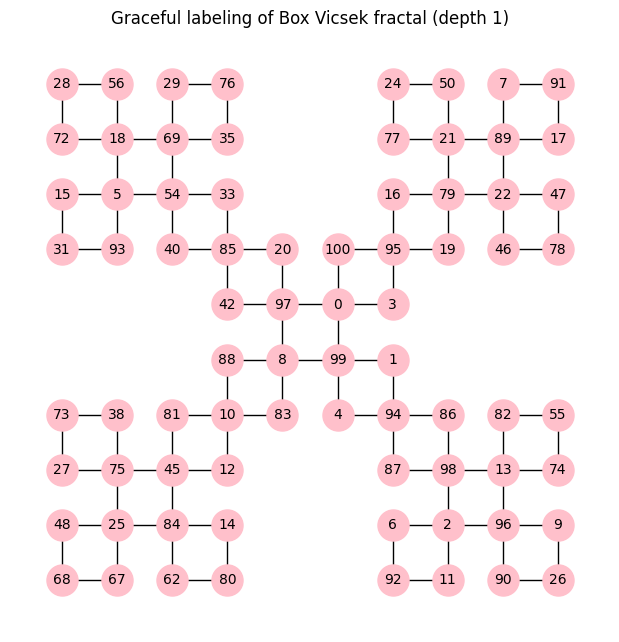

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from ortools.sat.python import cp_model


def build_box_vicsek(depth: int):
    """Construct the box Vicsek fractal graph (square polygonal system)."""
    squares = {(0,0)}
    copy_offsets = [(0,0), (0,2), (2,0), (2,2), (1,1)]
    for _ in range(depth):
        new_squares = set()
        for (x,y) in squares:
            for dx,dy in copy_offsets:
                new_squares.add((3*x + dx, 3*y + dy))
        squares = new_squares

    vertices = set()
    edges = set()
    for (x,y) in squares:
        v0 = (x,y); v1 = (x+1,y); v2 = (x+1,y+1); v3 = (x,y+1)
        verts = [v0,v1,v2,v3]
        for v in verts: vertices.add(v)
        square_edges = [(v0,v1),(v1,v2),(v2,v3),(v3,v0)]
        for a,b in square_edges:
            edges.add(tuple(sorted([a,b])))

    sorted_vertices = sorted(vertices)
    coord_to_node = {c:i for i,c in enumerate(sorted_vertices)}
    G = nx.Graph()
    for coord,nid in coord_to_node.items():
        G.add_node(nid, coord=coord)
    for a,b in edges:
        G.add_edge(coord_to_node[a], coord_to_node[b])

    pos = {coord_to_node[c]: (c[0],c[1]) for c in sorted_vertices}
    return G, pos

def graceful_labeling(G):
    """Find a graceful labeling using OR-Tools CP-SAT solver."""
    n = G.number_of_nodes()
    m = G.number_of_edges()

    model = cp_model.CpModel()

    # vertex labels in 0..m
    labels = {v: model.NewIntVar(0, m, f"x{v}") for v in G.nodes()}
    model.AddAllDifferent(list(labels.values()))

    # edge labels = |label[u]-label[v]|
    edge_labels = []
    for i,(u,v) in enumerate(G.edges()):
        diff = model.NewIntVar(1, m, f"d{i}")
        model.AddAbsEquality(diff, labels[u] - labels[v])
        edge_labels.append(diff)

    model.AddAllDifferent(edge_labels)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 30  # safety timeout
    status = solver.Solve(model)

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        vlabel = {v: solver.Value(labels[v]) for v in G.nodes()}
        elabel = {e: solver.Value(diff) for e,diff in zip(G.edges(), edge_labels)}
        return vlabel, elabel
    else:
        return None, None

# --- Build depth 1 Vicsek (box) graph ---
G, pos = build_box_vicsek(depth=2)
print(f"Depth 1: vertices={G.number_of_nodes()}, edges={G.number_of_edges()}")

# --- Solve graceful labeling ---
vlabel, elabel = graceful_labeling(G)

if vlabel:
    print("Graceful labeling found!")
    print("Vertex labels:", vlabel)
    print("Edge labels:", list(elabel.values()))

    # --- Plot graph with vertex labels ---
    plt.figure(figsize=(6,6))
    nx.draw(G, pos, with_labels=True,
            labels=vlabel, node_size=500,
            font_size=10, node_color="pink")
    plt.title("Graceful labeling of Box Vicsek fractal (depth 1)")
    plt.axis('equal')
    plt.show()
else:
    print("No graceful labeling found (within time limit).")

Depth 1: vertices=16, edges=20
Odd graceful labeling found!
Vertex labels: {0: 39, 1: 2, 2: 1, 3: 26, 4: 0, 5: 3, 6: 36, 7: 5, 8: 37, 9: 8, 10: 19, 11: 34, 12: 24, 13: 15, 14: 38, 15: 11}
Edge labels: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39]


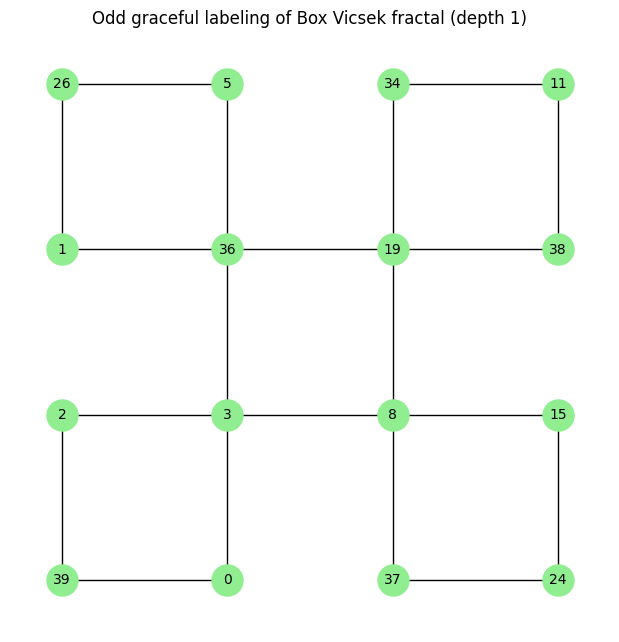

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from ortools.sat.python import cp_model


def build_box_vicsek(depth: int):
    """Construct the box Vicsek fractal graph (square polygonal system)."""
    squares = {(0,0)}
    copy_offsets = [(0,0), (0,2), (2,0), (2,2), (1,1)]
    for _ in range(depth):
        new_squares = set()
        for (x,y) in squares:
            for dx,dy in copy_offsets:
                new_squares.add((3*x + dx, 3*y + dy))
        squares = new_squares

    vertices = set()
    edges = set()
    for (x,y) in squares:
        v0 = (x,y); v1 = (x+1,y); v2 = (x+1,y+1); v3 = (x,y+1)
        verts = [v0,v1,v2,v3]
        for v in verts: vertices.add(v)
        square_edges = [(v0,v1),(v1,v2),(v2,v3),(v3,v0)]
        for a,b in square_edges:
            edges.add(tuple(sorted([a,b])))

    sorted_vertices = sorted(vertices)
    coord_to_node = {c:i for i,c in enumerate(sorted_vertices)}
    G = nx.Graph()
    for coord,nid in coord_to_node.items():
        G.add_node(nid, coord=coord)
    for a,b in edges:
        G.add_edge(coord_to_node[a], coord_to_node[b])

    pos = {coord_to_node[c]: (c[0],c[1]) for c in sorted_vertices}
    return G, pos

def graceful_labeling(G):
    """Find a graceful labeling using OR-Tools CP-SAT solver."""
    n = G.number_of_nodes()
    m = G.number_of_edges()

    model = cp_model.CpModel()

    # vertex labels in 0..m
    labels = {v: model.NewIntVar(0, m, f"x{v}") for v in G.nodes()}
    model.AddAllDifferent(list(labels.values()))

    # edge labels = |label[u]-label[v]|
    edge_labels = []
    for i,(u,v) in enumerate(G.edges()):
        diff = model.NewIntVar(1, m, f"d{i}")
        model.AddAbsEquality(diff, labels[u] - labels[v])
        edge_labels.append(diff)

    model.AddAllDifferent(edge_labels)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 30  # safety timeout
    status = solver.Solve(model)

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        vlabel = {v: solver.Value(labels[v]) for v in G.nodes()}
        elabel = {e: solver.Value(diff) for e,diff in zip(G.edges(), edge_labels)}
        return vlabel, elabel
    else:
        return None, None

# --- Build depth 1 Vicsek (box) graph ---
G, pos = build_box_vicsek(depth=1)
print(f"Depth 1: vertices={G.number_of_nodes()}, edges={G.number_of_edges()}")

# --- Solve graceful labeling ---
vlabel, elabel = graceful_labeling(G)

if vlabel:
    print("Graceful labeling found!")
    print("Vertex labels:", vlabel)
    print("Edge labels:", list(elabel.values()))

    # --- Plot graph with vertex labels ---
    plt.figure(figsize=(6,6))
    nx.draw(G, pos, with_labels=True,
            labels=vlabel, node_size=500,
            font_size=10, node_color="lightblue")
    plt.title("Graceful labeling of Box Vicsek fractal (depth 1)")
    plt.axis('equal')
    plt.show()
else:
    print("No graceful labeling found (within time limit).")

Depth 1: vertices=76, edges=100
Odd graceful labeling found!
Vertex labels: {0: 47, 1: 172, 2: 5, 3: 196, 4: 39, 5: 186, 6: 187, 7: 36, 8: 22, 9: 141, 10: 26, 11: 115, 12: 74, 13: 85, 14: 122, 15: 185, 16: 21, 17: 184, 18: 49, 19: 32, 20: 13, 21: 182, 22: 17, 23: 56, 24: 180, 25: 53, 26: 64, 27: 3, 28: 2, 29: 1, 30: 6, 31: 25, 32: 86, 33: 173, 34: 192, 35: 189, 36: 198, 37: 19, 38: 147, 39: 8, 40: 55, 41: 0, 42: 15, 43: 66, 44: 43, 45: 120, 46: 153, 47: 100, 48: 199, 49: 24, 50: 129, 51: 38, 52: 168, 53: 7, 54: 92, 55: 9, 56: 4, 57: 197, 58: 20, 59: 91, 60: 87, 61: 190, 62: 133, 63: 40, 64: 143, 65: 76, 66: 149, 67: 12, 68: 194, 69: 23, 70: 10, 71: 195, 72: 30, 73: 171, 74: 70, 75: 145}
Edge labels: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67, 69, 71, 73, 75, 77, 79, 81, 83, 85, 87, 89, 91, 93, 95, 97, 99, 101, 103, 105, 107, 109, 111, 113, 115, 117, 119, 121, 123, 125, 127, 129, 131, 133, 135, 137, 

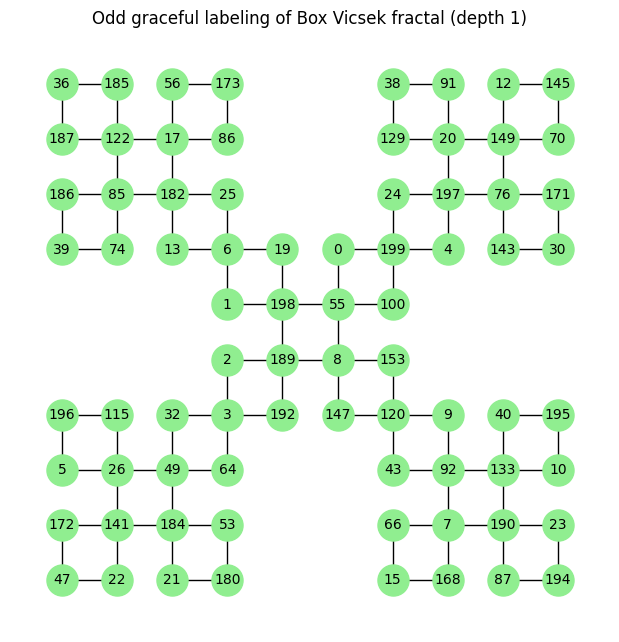

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from ortools.sat.python import cp_model


def build_box_vicsek(depth: int):
    """Construct the box Vicsek fractal graph (square polygonal system)."""
    squares = {(0,0)}
    copy_offsets = [(0,0), (0,2), (2,0), (2,2), (1,1)]
    for _ in range(depth):
        new_squares = set()
        for (x,y) in squares:
            for dx,dy in copy_offsets:
                new_squares.add((3*x + dx, 3*y + dy))
        squares = new_squares

    vertices = set()
    edges = set()
    for (x,y) in squares:
        v0 = (x,y); v1 = (x+1,y); v2 = (x+1,y+1); v3 = (x,y+1)
        verts = [v0,v1,v2,v3]
        for v in verts: vertices.add(v)
        square_edges = [(v0,v1),(v1,v2),(v2,v3),(v3,v0)]
        for a,b in square_edges:
            edges.add(tuple(sorted([a,b])))

    sorted_vertices = sorted(vertices)
    coord_to_node = {c:i for i,c in enumerate(sorted_vertices)}
    G = nx.Graph()
    for coord,nid in coord_to_node.items():
        G.add_node(nid, coord=coord)
    for a,b in edges:
        G.add_edge(coord_to_node[a], coord_to_node[b])

    pos = {coord_to_node[c]: (c[0],c[1]) for c in sorted_vertices}
    return G, pos


def odd_graceful_labeling(G):
    """Find an odd graceful labeling using OR-Tools CP-SAT solver."""
    n = G.number_of_nodes()
    q = G.number_of_edges()

    model = cp_model.CpModel()

    # Vertex labels in 0..2q-1
    labels = {v: model.NewIntVar(0, 2*q-1, f"x{v}") for v in G.nodes()}
    model.AddAllDifferent(list(labels.values()))

    # Edge labels must be odd: {1,3,5,...,2q-1}
    edge_labels = []
    for i,(u,v) in enumerate(G.edges()):
        diff = model.NewIntVar(1, 2*q-1, f"d{i}")
        model.AddAbsEquality(diff, labels[u] - labels[v])

        # Restrict to odd values
        is_odd = model.NewBoolVar(f"odd{i}")
        model.AddModuloEquality(is_odd, diff, 2)   # is_odd = diff % 2
        model.Add(is_odd == 1)

        edge_labels.append(diff)

    # All edge labels distinct
    model.AddAllDifferent(edge_labels)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 100  # 1 minute timeout
    status = solver.Solve(model)

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        vlabel = {v: solver.Value(labels[v]) for v in G.nodes()}
        elabel = {e: solver.Value(diff) for e,diff in zip(G.edges(), edge_labels)}
        return vlabel, elabel
    else:
        return None, None


# --- Example: Build depth=1 Vicsek (box) graph ---
G, pos = build_box_vicsek(depth=2)
print(f"Depth 1: vertices={G.number_of_nodes()}, edges={G.number_of_edges()}")

# --- Solve odd graceful labeling ---
vlabel, elabel = odd_graceful_labeling(G)

if vlabel:
    print("Odd graceful labeling found!")
    print("Vertex labels:", vlabel)
    print("Edge labels:", sorted(elabel.values()))

    # --- Plot graph with vertex labels ---
    plt.figure(figsize=(6,6))
    nx.draw(G, pos, with_labels=True,
            labels=vlabel, node_size=500,
            font_size=10, node_color="lightgreen")
    plt.title("Odd graceful labeling of Box Vicsek fractal (depth 1)")
    plt.axis('equal')
    plt.show()
else:
    print("No odd graceful labeling found (within time limit).")
